# Stage-I SD-EWMA Covariate-Shift Detection

This notebook implements the online **Stage-I SD-EWMA** workflow for the
synthetic Gaussian mean-shift stream.

The objectives are to:

- estimate the EWMA smoothing parameter from stationary training data;
- fit the initial EWMA state and prediction-error variance;
- detect observations outside the moving control limits;
- report first detection time, false positives, false negatives, RCI and runtime;
- visualise the detector response around the known shift point.

Stage-II statistical validation is outside the scope of this notebook.


## 1. Environment setup


In [1]:
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start_path: Path) -> Path:
    """Find the project directory containing src/ and notebooks/."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import evaluate_stage_1_detection
from src.ewma import (
    SD_EWMA_Config,
    estimate_lambda,
    fit_sd_ewma,
    run_sd_ewma,
)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\haoch\OneDrive\Desktop\ewma_covariate_shift_demo\ewma_covariate_shift_demo


## 2. Load the synthetic Gaussian stream


In [2]:
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "gaussian_mean_shift.csv"
)

gaussian_stream = pd.read_csv(RAW_DATA_PATH)

required_columns = {
    "time",
    "x",
    "true_regime",
    "true_shift",
}

missing_columns = required_columns.difference(gaussian_stream.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

print(f"Loaded: {RAW_DATA_PATH}")
print(f"Shape: {gaussian_stream.shape}")

gaussian_stream.head()


Loaded: C:\Users\haoch\OneDrive\Desktop\ewma_covariate_shift_demo\ewma_covariate_shift_demo\data\raw\gaussian_mean_shift.csv
Shape: (1000, 4)


,time,x,true_regime,true_shift
0,0,0.304717,before_shift,0
1,1,-1.039984,before_shift,0
2,2,0.750451,before_shift,0
3,3,0.940565,before_shift,0
4,4,-1.951035,before_shift,0


## 3. Define the training and online-testing data

The stationary `before_shift` observations are used for retrospective
training. The remaining observations form the online Stage-I testing stream.


In [3]:
training_data = (
    gaussian_stream.loc[
        gaussian_stream["true_regime"] == "before_shift"
    ]
    .copy()
)

testing_data = (
    gaussian_stream.loc[
        gaussian_stream["true_regime"] != "before_shift"
    ]
    .copy()
)

if training_data.empty:
    raise ValueError("The training dataset is empty.")

if testing_data.empty:
    raise ValueError("The testing dataset is empty.")

shift_times = gaussian_stream.loc[
    gaussian_stream["true_shift"] == 1,
    "time",
].to_numpy()

if len(shift_times) != 1:
    raise ValueError("Expected exactly one true shift point.")

true_shift_time = int(shift_times[0])

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Online testing"],
    "Observations": [len(training_data), len(testing_data)],
    "Start time": [
        int(training_data["time"].min()),
        int(testing_data["time"].min()),
    ],
    "End time": [
        int(training_data["time"].max()),
        int(testing_data["time"].max()),
    ],
})

print(f"True shift time: {true_shift_time}")
split_summary


True shift time: 500


,Dataset,Observations,Start time,End time
0,Training,500,0,499
1,Online testing,500,500,999


## 4. Select the EWMA smoothing parameter

Following Section 3.1 and Table 1 of the paper, the smoothing parameter
$\lambda$ is selected by minimising the sum of squared one-step-ahead
prediction errors over the stationary training data.


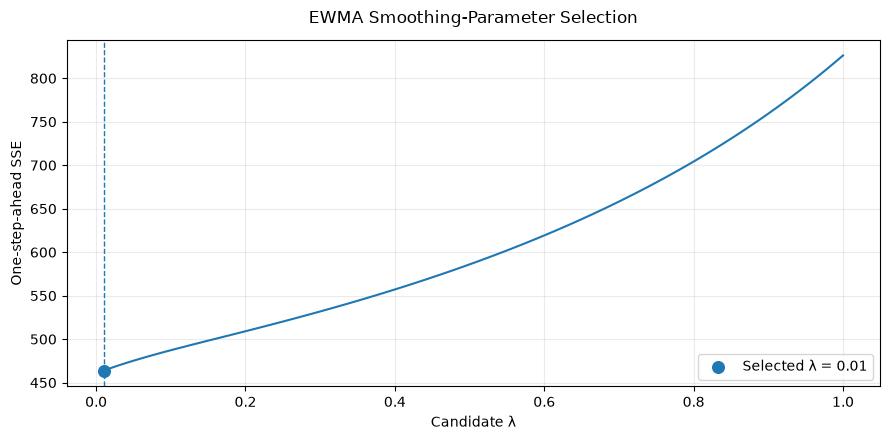

Selected lambda: 0.01


In [4]:
best_lambda, lambda_results = estimate_lambda(
    training_data["x"].to_numpy()
)

selected_row = lambda_results.loc[
    lambda_results["lambda"] == best_lambda
].iloc[0]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    lambda_results["lambda"],
    lambda_results["sse"],
    linewidth=1.5,
)

ax.scatter(
    selected_row["lambda"],
    selected_row["sse"],
    s=70,
    zorder=3,
    label=f"Selected λ = {best_lambda:.2f}",
)

ax.axvline(
    best_lambda,
    linestyle="--",
    linewidth=1.0,
)

ax.set_title("EWMA Smoothing-Parameter Selection", pad=12)
ax.set_xlabel("Candidate λ")
ax.set_ylabel("One-step-ahead SSE")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Selected lambda: {best_lambda:.2f}")


### Lambda-selection result

The selected value is specific to this generated training sample. A minimum
at the lower edge of the candidate grid indicates that the sample favours
strong smoothing and should be investigated in later sensitivity experiments.


## 5. Fit the Stage-I EWMA model


In [5]:
training_result = fit_sd_ewma(
    training_data["x"].to_numpy()
)

training_summary = pd.DataFrame({
    "Parameter": [
        "Selected lambda",
        "Initial EWMA state",
        "Final training EWMA state",
        "Error variance",
        "Error standard deviation",
    ],
    "Value": [
        training_result.lambda_value,
        training_result.initial_z,
        training_result.final_z,
        training_result.error_variance,
        training_result.error_standard_deviation,
    ],
})

training_summary["Value"] = training_summary["Value"].map(
    lambda value: f"{value:.4f}"
)

training_summary


,Parameter,Value
0,Selected lambda,0.0100
1,Initial EWMA state,-0.0131
2,Final training EWMA state,-0.0124
3,Error variance,0.9274
4,Error standard deviation,0.9630


## 6. Run online Stage-I detection


In [6]:
detector_config = SD_EWMA_Config(
    lambda_value=training_result.lambda_value,
    variance_smoothing=0.05,
    control_limit_multiplier=3.0,
)

start_time = perf_counter()

stage_1_results = run_sd_ewma(
    values=testing_data["x"].to_numpy(),
    times=testing_data["time"].to_numpy(),
    initial_z=training_result.final_z,
    initial_error_variance=training_result.error_variance,
    config=detector_config,
)

computation_time_seconds = perf_counter() - start_time

stage_1_results = stage_1_results.merge(
    testing_data[
        [
            "time",
            "true_regime",
            "true_shift",
        ]
    ],
    on="time",
    how="left",
)

print(
    "Stage-I runtime: "
    f"{computation_time_seconds * 1000:.3f} ms"
)

stage_1_results.head()


Stage-I runtime: 4.220 ms


,time,x,prediction,ewma,error,lcl,ucl,stage_1_alarm,true_regime,true_shift
0,500,3.363862,-0.012404,0.021359,3.376266,-2.901380,2.876572,1,after_shift,1
1,501,2.895185,0.021359,0.050097,2.873826,-3.592296,3.635014,0,after_shift,0
2,502,1.280520,0.050097,0.062401,1.230423,-3.965133,4.065327,0,after_shift,0
3,503,0.497497,0.062401,0.066752,0.435095,-3.937254,4.062056,0,after_shift,0
4,504,-0.964529,0.066752,0.056439,-1.031281,-3.842540,3.976045,0,after_shift,0


## 7. Evaluate Stage-I performance


In [7]:
metrics = evaluate_stage_1_detection(
    results=stage_1_results,
    true_shift_time=true_shift_time,
    computation_time_seconds=computation_time_seconds,
)

if metrics.shift_detected:
    print(
        "Stage-I result: shift detected at "
        f"observation {metrics.first_detection_time} "
        f"with RCI = {metrics.recognition_capability_index}."
    )
else:
    print("Stage-I result: no post-shift alarm detected.")

false_positive_rate_display = (
    "Not applicable"
    if np.isnan(metrics.false_positive_rate)
    else f"{metrics.false_positive_rate * 100:.2f}%"
)

metrics_summary = pd.DataFrame([{
    "Method": "SD-EWMA",
    "Shift detected": "Yes" if metrics.shift_detected else "No",
    "True shift": true_shift_time,
    "First alarm": metrics.first_detection_time,
    "RCI": metrics.recognition_capability_index,
    "False positives": metrics.false_positive_count,
    "False-positive rate": false_positive_rate_display,
    "False negatives": metrics.false_negative_count,
    "Runtime (ms)": f"{metrics.computation_time_seconds * 1000:.3f}",
}])

metrics_summary


Stage-I result: shift detected at observation 500 with RCI = 0.


,Method,Shift detected,True shift,First alarm,RCI,False positives,False-positive rate,False negatives,Runtime (ms)
0,SD-EWMA,Yes,500,500,0,0,Not applicable,0,4.220


### Alarm events

The table below lists every observation that crossed a Stage-I control limit.
It provides a direct audit trail for the summary metrics.


In [8]:
alarm_summary = (
    stage_1_results.loc[
        stage_1_results["stage_1_alarm"] == 1,
        [
            "time",
            "x",
            "prediction",
            "lcl",
            "ucl",
            "true_regime",
        ],
    ]
    .rename(columns={
        "time": "Observation",
        "x": "Observed value",
        "prediction": "EWMA prediction",
        "lcl": "LCL",
        "ucl": "UCL",
        "true_regime": "True regime",
    })
    .reset_index(drop=True)
)

alarm_summary.round(3)


,Observation,Observed value,EWMA prediction,LCL,UCL,True regime
0,500,3.364,-0.012,-2.901,2.877,after_shift
1,506,4.420,0.070,-3.819,3.960,after_shift
2,947,-0.931,1.999,-0.568,4.565,after_shift
3,949,-1.648,1.974,-1.139,5.086,after_shift


## 8. Visualise the detection results


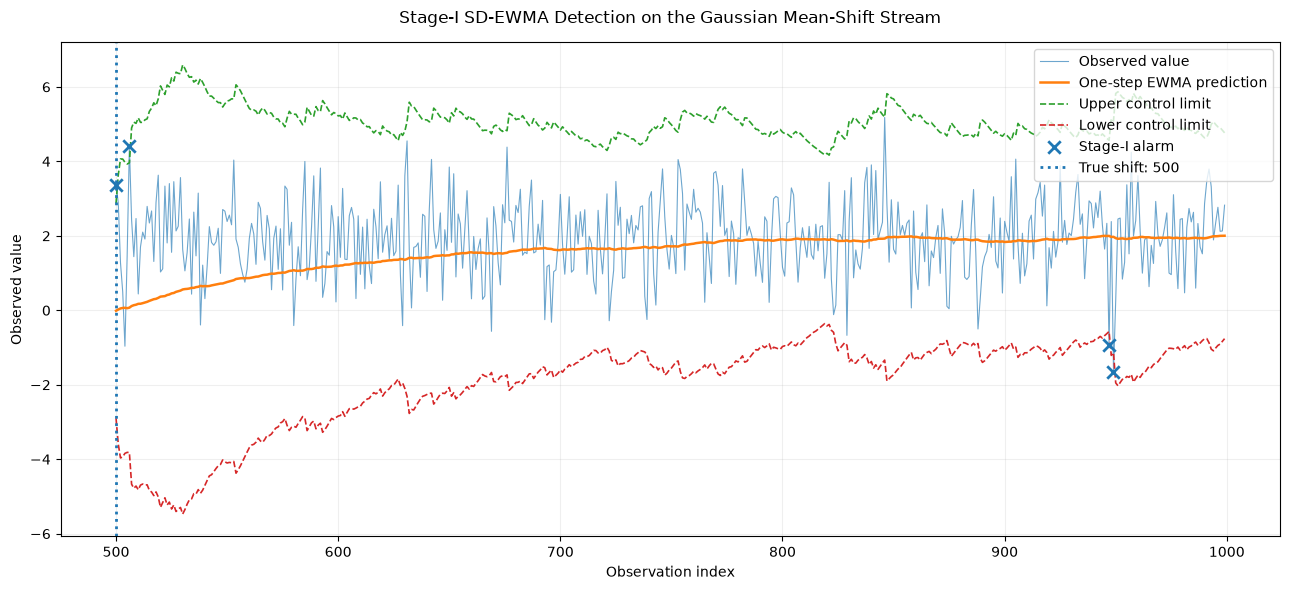

In [9]:
def plot_stage_1_results(
    results: pd.DataFrame,
    shift_time: int,
    title: str,
) -> None:
    """Plot observations, predictions, limits and Stage-I alarms."""
    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(
        results["time"],
        results["x"],
        linewidth=0.8,
        alpha=0.65,
        label="Observed value",
    )

    ax.plot(
        results["time"],
        results["prediction"],
        linewidth=1.8,
        label="One-step EWMA prediction",
    )

    ax.plot(
        results["time"],
        results["ucl"],
        linestyle="--",
        linewidth=1.2,
        label="Upper control limit",
    )

    ax.plot(
        results["time"],
        results["lcl"],
        linestyle="--",
        linewidth=1.2,
        label="Lower control limit",
    )

    alarm_rows = results.loc[
        results["stage_1_alarm"] == 1
    ]

    ax.scatter(
        alarm_rows["time"],
        alarm_rows["x"],
        marker="x",
        s=80,
        linewidths=2,
        zorder=4,
        label="Stage-I alarm",
    )

    ax.axvline(
        shift_time,
        linestyle=":",
        linewidth=2,
        label=f"True shift: {shift_time}",
    )

    ax.set_title(title, pad=14)
    ax.set_xlabel("Observation index")
    ax.set_ylabel("Observed value")
    ax.legend(loc="upper right", frameon=True)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_stage_1_results(
    results=stage_1_results,
    shift_time=true_shift_time,
    title=(
        "Stage-I SD-EWMA Detection on the "
        "Gaussian Mean-Shift Stream"
    ),
)


### Focused view around the true shift


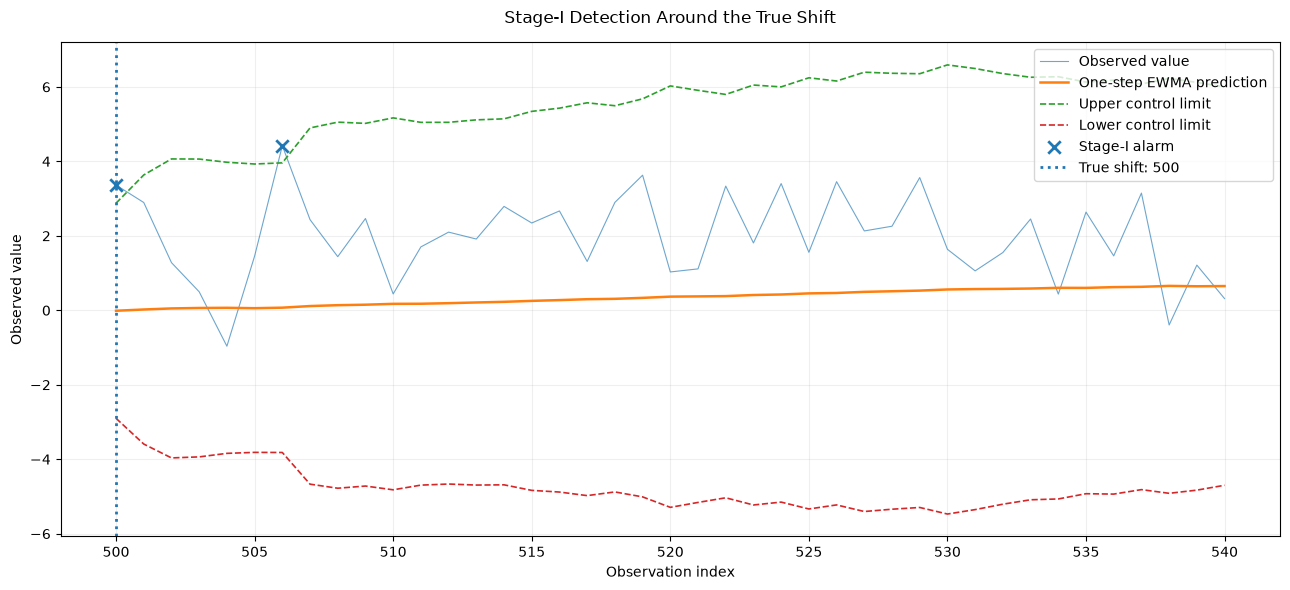

In [10]:
window_start = max(
    int(stage_1_results["time"].min()),
    true_shift_time - 20,
)

window_end = min(
    int(stage_1_results["time"].max()),
    true_shift_time + 40,
)

focused_results = stage_1_results.loc[
    stage_1_results["time"].between(
        window_start,
        window_end,
    )
]

plot_stage_1_results(
    results=focused_results,
    shift_time=true_shift_time,
    title="Stage-I Detection Around the True Shift",
)


## 9. Stage-I interpretation and limitations

The Stage-I detector is evaluated against the known synthetic shift using
first-alarm timing, false positives, false negatives, RCI and runtime.

The false-positive result must be interpreted carefully. In the current
dataset, online testing begins at the true shift point, so there is no
stationary pre-shift online interval in which false alarms could occur.
Accordingly, the notebook demonstrates Stage-I operation and shift
recognition, but it does not yet provide a complete false-positive-rate
experiment.

A later experiment should introduce a stationary online-testing segment
before the shift and compare Stage-I alarms with Stage-II statistical
validation.


In [11]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
RESULTS_DIR = OUTPUT_DIR / "results"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"

for directory in [
    RESULTS_DIR,
    METRICS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

In [12]:
stage_1_results.to_csv(
    RESULTS_DIR / "sd_ewma_stage_1_results.csv",
    index=False,
)

In [13]:
metrics_summary.to_csv(
    METRICS_DIR / "sd_ewma_stage_1_metrics.csv",
    index=False,
)

In [14]:
fig.savefig(
    FIGURES_DIR / "sd_ewma_stage_1_overview.png",
    dpi=300,
    bbox_inches="tight",
)